In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [201]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/3-customersatisfaction.csv")

In [202]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [203]:
df = df.drop(columns=("Unnamed: 0"))

In [204]:
df 

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365
...,...,...
95,2.055072,8.686851
96,0.864149,2.901486
97,-1.586101,0.786207
98,1.558528,5.447475


In [205]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


Text(0, 0.5, 'Incentive')

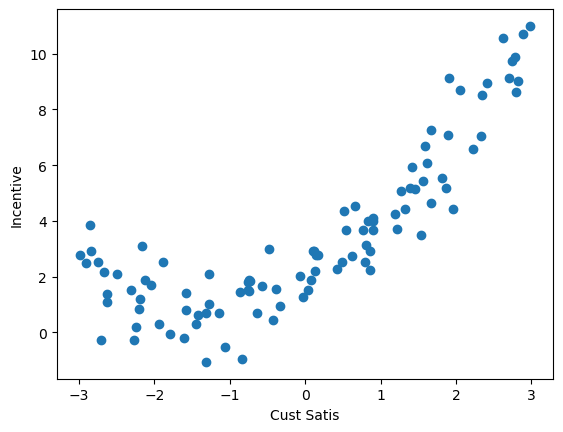

In [207]:
plt.scatter(df["Customer Satisfaction"], df["Incentive"])
plt.xlabel("Cust Satis")
plt.ylabel("Incentive")

# polinom çizgisi

In [208]:
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [209]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=15)

In [210]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [211]:
scaler = StandardScaler()

In [212]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [213]:
regression = LinearRegression()

In [214]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [215]:
y_pred = regression.predict(X_test)

In [216]:
score = r2_score(y_test, y_pred)

In [217]:
print(score)

0.2705652535622243


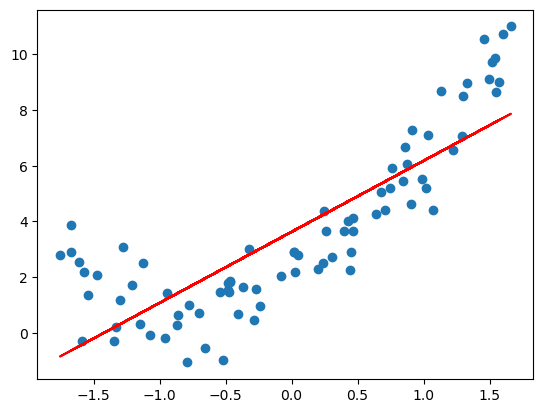

In [218]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = "r")

In [219]:
poly = PolynomialFeatures(degree = 2)

In [220]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [221]:
regression = LinearRegression()

In [222]:
regression.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [223]:
y_pred = regression.predict(X_test_poly)
r2_score(y_test, y_pred)

0.7685687698788558

In [224]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [225]:
regression.intercept_

np.float64(2.07667642979328)

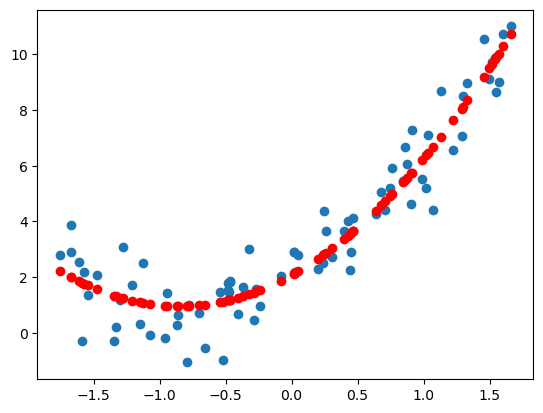

In [226]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")

In [227]:
poly = PolynomialFeatures(degree = 3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
r2_score(y_test, y_pred)

0.7573443621401051

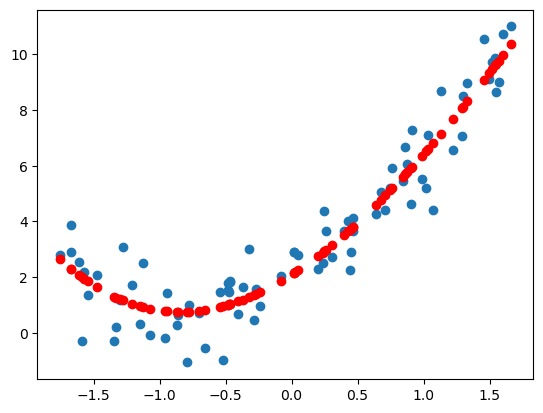

In [228]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")

In [229]:
# new data

In [230]:
new_df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/3-newdatas.csv")

In [231]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [232]:
new_df.rename(columns = {"0": "Customer Satisfaction"}, inplace = True)

In [233]:
X_new = new_df

In [234]:
X_new = scaler.fit_transform(X_new)

In [235]:
X_new_poly = poly.transform(X_new)

In [236]:
y_new_predict = regression.predict(X_new_poly)

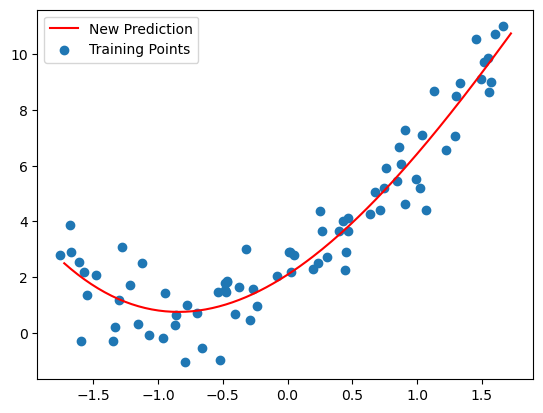

In [237]:
plt.plot(X_new, y_new_predict, "r", label = "New Prediction")
plt.scatter(X_train, y_train, label= "Training Points")
plt.legend()

In [238]:
# pipline

In [239]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    scaler = StandardScaler()
    pipeline = Pipeline([
        ("standard_scaler", scaler),
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print("R2 score: ", score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_new_predict, "r", label="New Predictions")
    plt.scatter(X_train, y_train, label="Training Points")
    plt.scatter(X_test, y_test, label="Test Points")
    plt.title(f"Degree = {degree}, R2 = {score:.3f}")
    plt.legend()
    plt.show()

R2 score:  0.27056525356222416


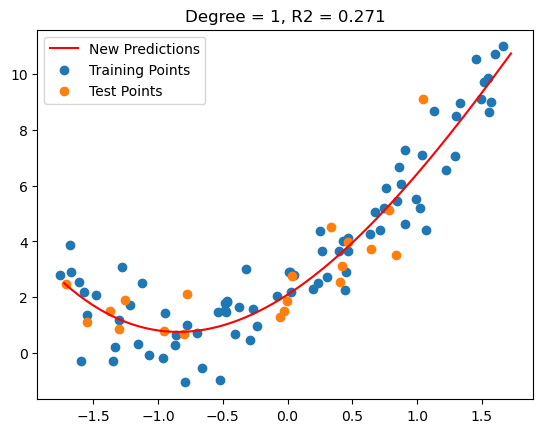

R2 score:  0.7685687698788558


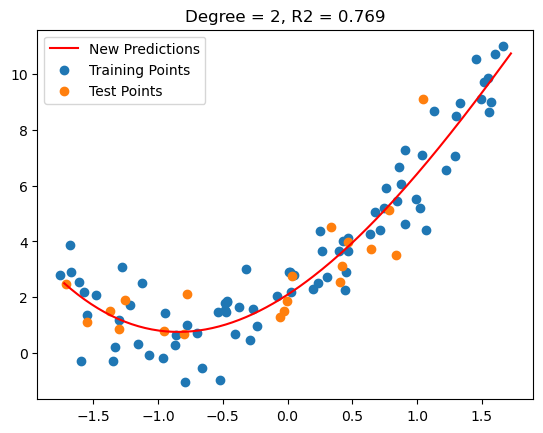

R2 score:  0.7573443621401051


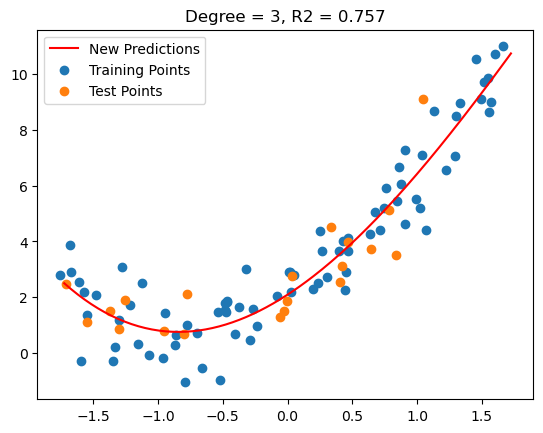

R2 score:  0.7355034443260418


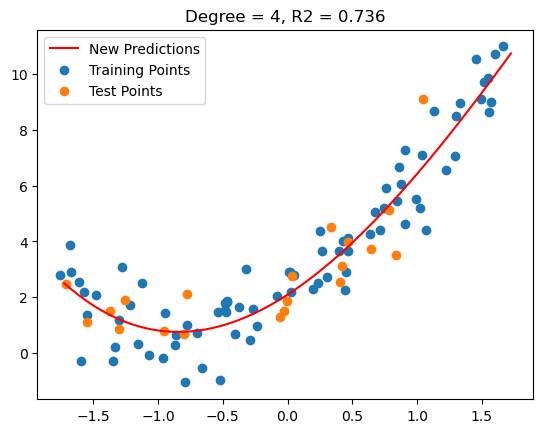

R2 score:  0.7351244165095403


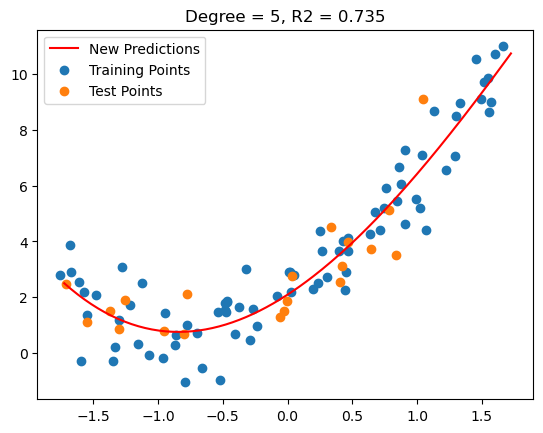

R2 score:  0.7343590482133427


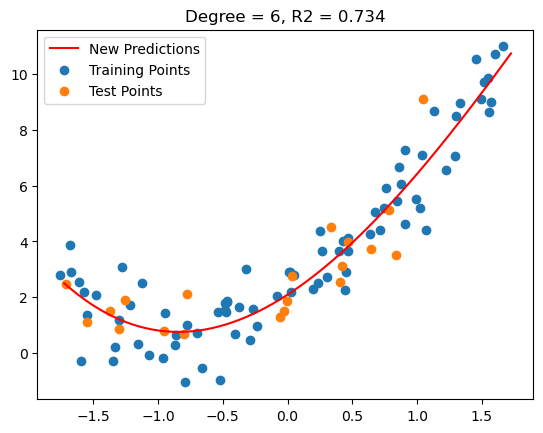

R2 score:  0.7347819263549453


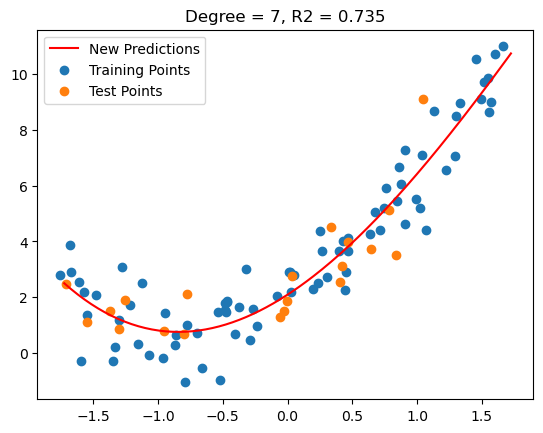

R2 score:  0.7411422099998388


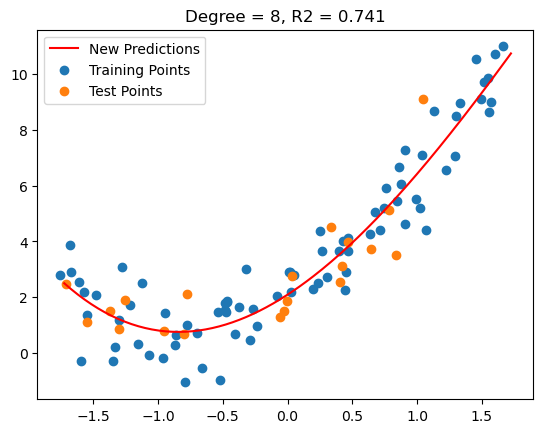

R2 score:  0.7310763879815905


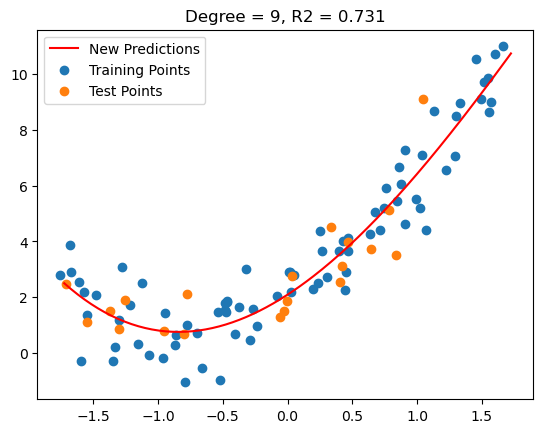

R2 score:  0.7280578621232858


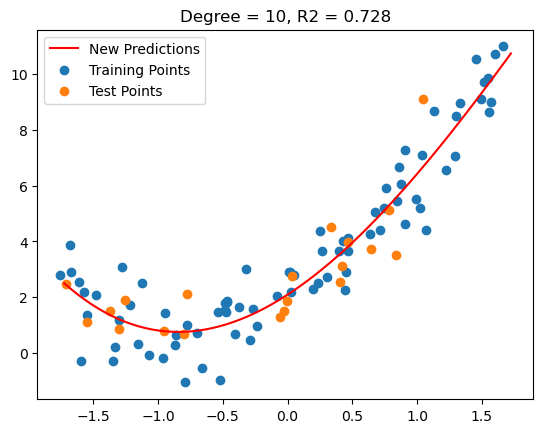

In [240]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)